# **Question 2 : (1)**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- Load Data ---
df = pd.read_csv("/home/banibrata/Desktop/cleveland_heart_attr.csv")
print("Shape:", df.shape)
print(df.dtypes)
df.sample(5)

Shape: (303, 14)
age                                       float64
sex                                       float64
chest_pain_type                           float64
rest_bp                                   float64
serum_cholesterol                         float64
fastblood_sugar                           float64
rest_ecg                                  float64
max_heartrate                             float64
exercise_angina                           float64
ST_depression_exercise_relativeto_rest    float64
slope_peak_STsegment                      float64
num_major_vessels_fluroscopy               object
thal                                       object
heart_disease_status                        int64
dtype: object


,age,sex,chest_pain_type,rest_bp,serum_cholesterol,fastblood_sugar,rest_ecg,max_heartrate,exercise_angina,ST_depression_exercise_relativeto_rest,slope_peak_STsegment,num_major_vessels_fluroscopy,thal,heart_disease_status
145,47.0,1.0,3.0,108.0,243.0,0.0,0.0,152.0,0.0,0.0,1.0,0.0,3.0,1
149,60.0,0.0,3.0,102.0,318.0,0.0,0.0,160.0,0.0,0.0,1.0,1.0,3.0,0
132,29.0,1.0,2.0,130.0,204.0,0.0,2.0,202.0,0.0,0.0,1.0,0.0,3.0,0
258,70.0,1.0,2.0,156.0,245.0,0.0,2.0,143.0,0.0,0.0,1.0,0.0,3.0,0
259,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,1


# **Question 2 : (2)**

In [2]:
print("""These two columns are considered object types because they contain non-numeric characters (e.g. '?') to represent missing values.
Pandas treats any column with such mixed (string + numeric) entries as an object dtype instead of numeric.
Once '?' is replaced by NaN, both columns can be converted to float.""")

These two columns are considered object types because they contain non-numeric characters (e.g. '?') to represent missing values.
Pandas treats any column with such mixed (string + numeric) entries as an object dtype instead of numeric.
Once '?' is replaced by NaN, both columns can be converted to float.


In [3]:
# Fix non-numeric columns and replace '?' with NaN
df_clean = df.copy()
df_clean['num_major_vessels_fluroscopy'] = df_clean['num_major_vessels_fluroscopy'].replace('?', np.nan)
df_clean['thal'] = df_clean['thal'].replace('?', np.nan)
df_clean['num_major_vessels_fluroscopy'] = pd.to_numeric(df_clean['num_major_vessels_fluroscopy'], errors='coerce')
df_clean['thal'] = pd.to_numeric(df_clean['thal'], errors='coerce')
print(df_clean.dtypes[['num_major_vessels_fluroscopy','thal']])

num_major_vessels_fluroscopy    float64
thal                            float64
dtype: object


# **Question 2 : (3,4)**

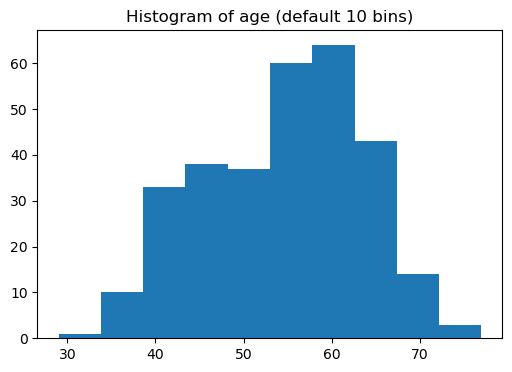

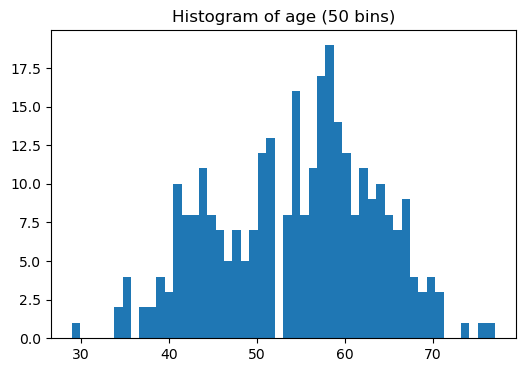

Age range: 29.0-77.0, bin_size_default=4.80, bin_size_50=0.96


In [4]:
age = df_clean['age'].dropna()
age_min, age_max = age.min(), age.max()
plt.figure(figsize=(6,4)); plt.hist(age, bins=10); plt.title('Histogram of age (default 10 bins)'); plt.show()
plt.figure(figsize=(6,4)); plt.hist(age, bins=50); plt.title('Histogram of age (50 bins)'); plt.show()
print(f"Age range: {age_min}-{age_max}, bin_size_default={(age_max-age_min)/10:.2f}, bin_size_50={(age_max-age_min)/50:.2f}")

# **Question 2 : (5)**

In [5]:
print("""KDE stands for Kernel Density Estimate.
It plots a smoothed continuous curve that estimates the probability density function (PDF) of the data.
KDE removes the dependence on the number or width of bins (unlike histograms) and helps visualize the underlying distribution shape (e.g., unimodal, bimodal, skewness).
""")

KDE stands for Kernel Density Estimate.
It plots a smoothed continuous curve that estimates the probability density function (PDF) of the data.
KDE removes the dependence on the number or width of bins (unlike histograms) and helps visualize the underlying distribution shape (e.g., unimodal, bimodal, skewness).



# **Question 2 : (6,7)**

246.69306930693068 241.0 211.0 275.0


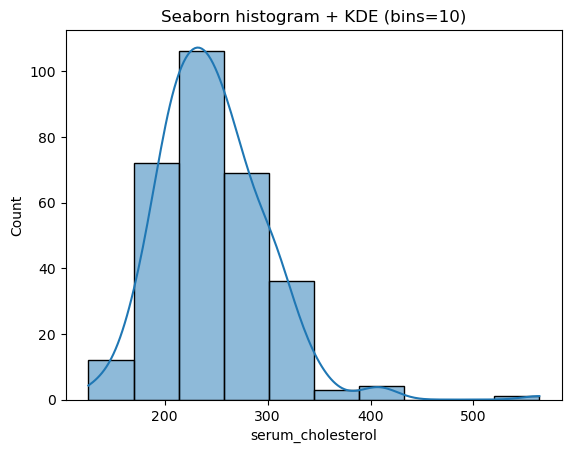

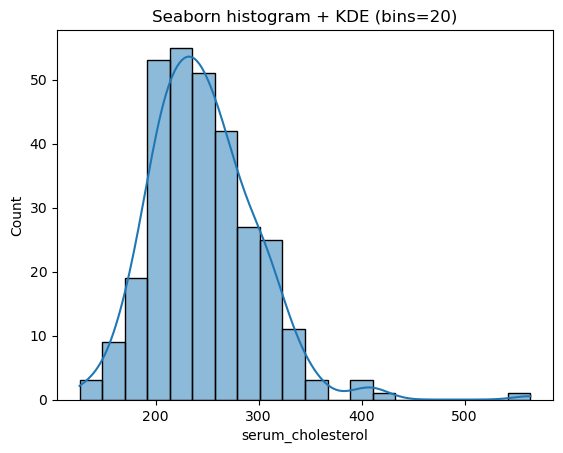

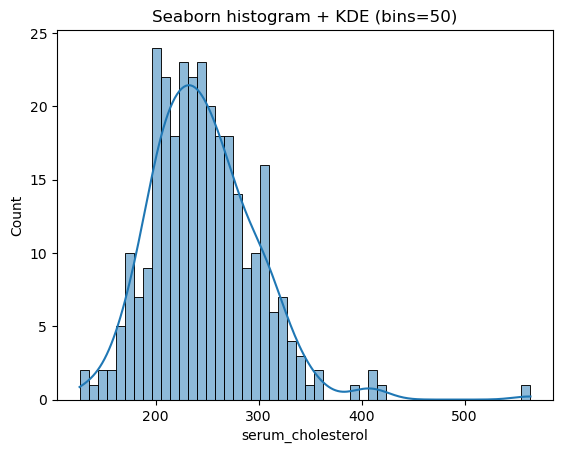

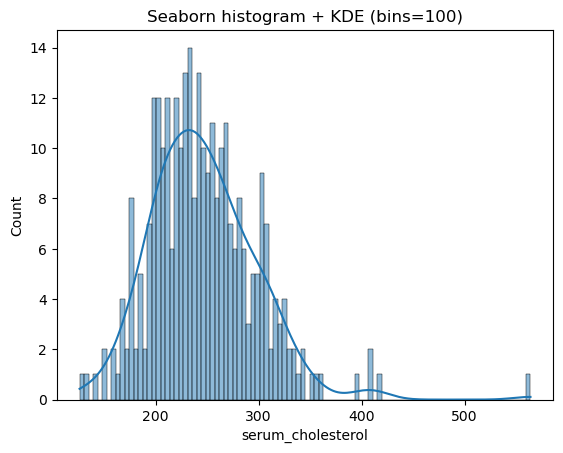

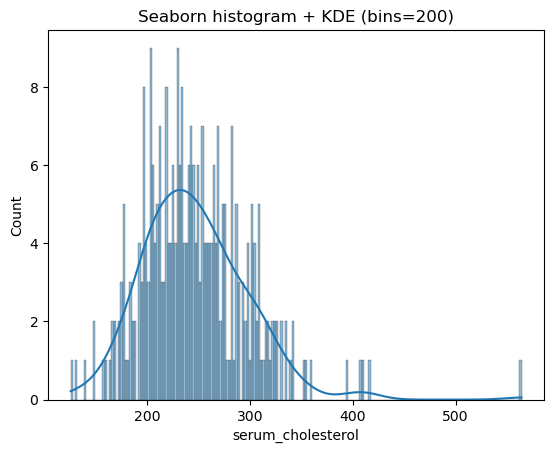

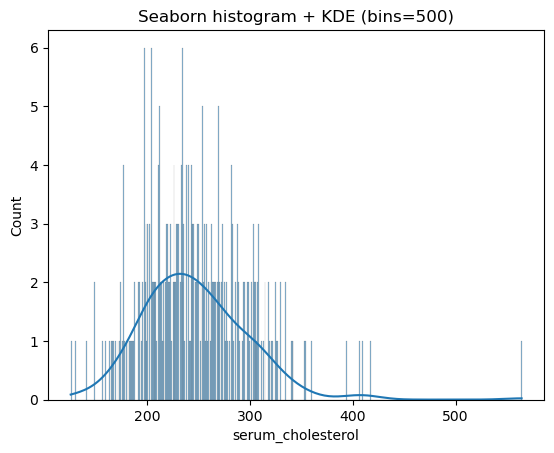

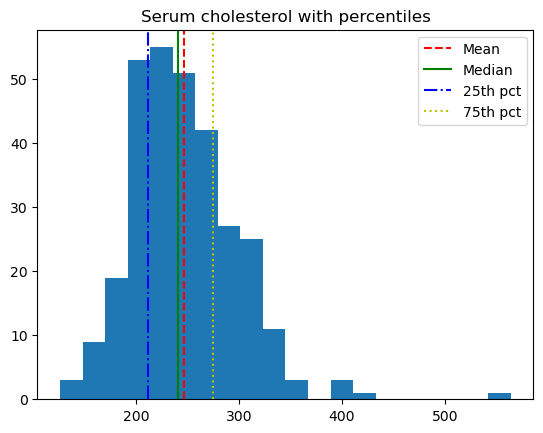

In [6]:
chol = df_clean['serum_cholesterol'].dropna()
mean_chol, median_chol = chol.mean(), chol.median()
q25, q75 = chol.quantile(0.25), chol.quantile(0.75)
print(mean_chol, median_chol, q25, q75)

for bins in [10, 20, 50, 100, 200, 500]:
    sns.histplot(chol, bins=bins, kde=True)
    plt.title(f"Seaborn histogram + KDE (bins={bins})")
    plt.show()

plt.hist(chol, bins=20)
plt.axvline(mean_chol, color='r', linestyle='--', label='Mean')
plt.axvline(median_chol, color='g', linestyle='-', label='Median')
plt.axvline(q25, color='b', linestyle='-.', label='25th pct')
plt.axvline(q75, color='y', linestyle=':', label='75th pct')
plt.legend(); plt.title('Serum cholesterol with percentiles'); plt.show()

# **Question 2 : (8)**

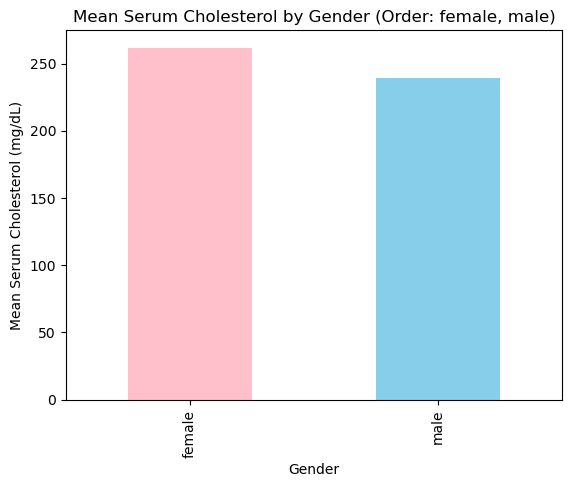

In [7]:
# Map gender values for readability
df['sex_label'] = df['sex'].map({1: 'male', 0: 'female'})

# Compute mean serum cholesterol per gender
mean_chol = df.groupby('sex_label')['serum_cholesterol'].mean()

# Reorder the gender order to female, male
gender_order = ['female', 'male']
mean_chol = mean_chol.reindex(gender_order)

# Plot the reordered bar plot
mean_chol.plot(kind='bar', color=['pink', 'skyblue'])
plt.title("Mean Serum Cholesterol by Gender (Order: female, male)")
plt.xlabel("Gender")
plt.ylabel("Mean Serum Cholesterol (mg/dL)")
plt.show()


In [8]:
print("""Reordering simply changes the x-axis sequence to show female first, then male — it does not affect the values or the bar heights.""")

Reordering simply changes the x-axis sequence to show female first, then male — it does not affect the values or the bar heights.


# **Question 2 : (9)**

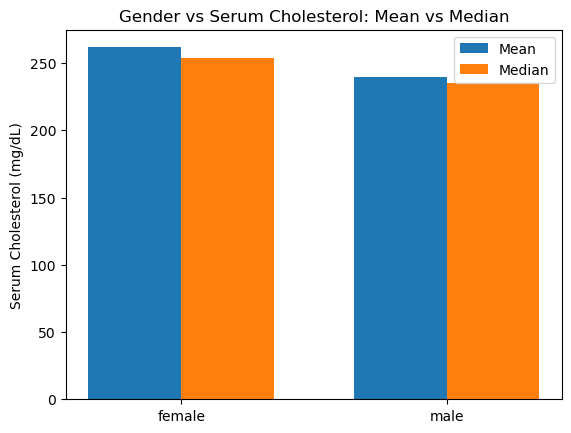

In [9]:
# Mean vs median comparison
mean_vals = df.groupby('sex_label')['serum_cholesterol'].mean()
median_vals = df.groupby('sex_label')['serum_cholesterol'].median()

# Combined plot
x = np.arange(len(mean_vals))
width = 0.35
plt.bar(x - width/2, mean_vals, width=width, label='Mean')
plt.bar(x + width/2, median_vals, width=width, label='Median')
plt.xticks(x, mean_vals.index)
plt.ylabel("Serum Cholesterol (mg/dL)")
plt.title("Gender vs Serum Cholesterol: Mean vs Median")
plt.legend()
plt.show()


In [10]:
print("""The mean plot is sensitive to outliers — high cholesterol values pull the bars upward.
The median plot reflects the central tendency more robustly.
In this dataset, the mean is slightly higher than the median (right-skewed distribution).
Hence, median bars are slightly lower and represent typical values better.""")

The mean plot is sensitive to outliers — high cholesterol values pull the bars upward.
The median plot reflects the central tendency more robustly.
In this dataset, the mean is slightly higher than the median (right-skewed distribution).
Hence, median bars are slightly lower and represent typical values better.


# **Question 2 : (10)**

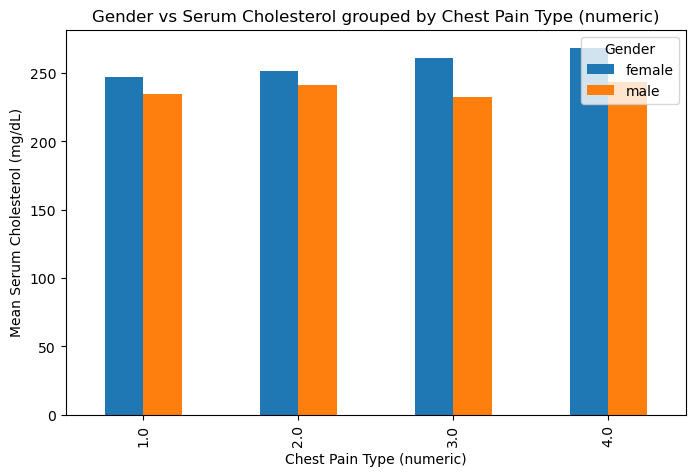

In [11]:
# Group mean serum cholesterol by chest pain type (numeric)
grouped = df.groupby(['chest_pain_type', 'sex_label'])['serum_cholesterol'].mean().unstack()
grouped.plot(kind='bar', figsize=(8,5))
plt.title("Gender vs Serum Cholesterol grouped by Chest Pain Type (numeric)")
plt.xlabel("Chest Pain Type (numeric)")
plt.ylabel("Mean Serum Cholesterol (mg/dL)")
plt.legend(title="Gender")
plt.show()

In [1]:
print("""Mean cholesterol levels vary by chest pain type.
Males generally have lower mean cholesterol than females.
However, since chest pain type is just a number (1–4), it’s not easy to interpret — adding descriptions (next question) will make the plot more meaningful.""")

Mean cholesterol levels vary by chest pain type.
Males generally have lower mean cholesterol than females.
However, since chest pain type is just a number (1–4), it’s not easy to interpret — adding descriptions (next question) will make the plot more meaningful.


# **Question 2 : (11)**

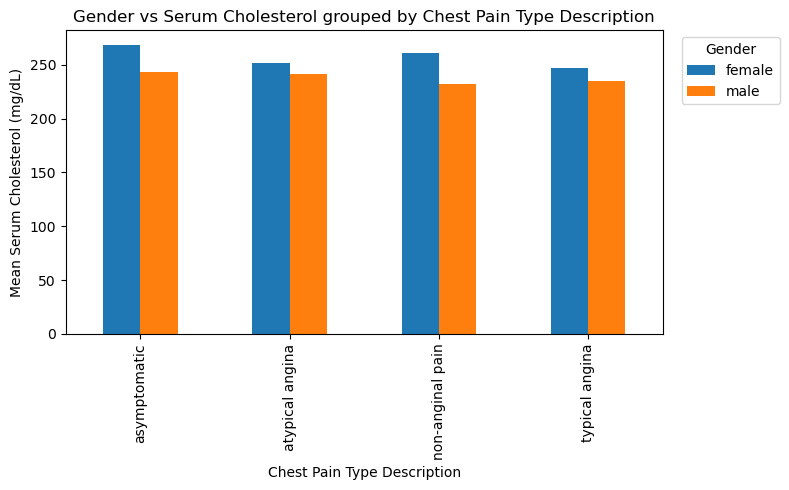

In [13]:
# Mapping from description file
cp_map = {
    1.0: "typical angina",
    2.0: "atypical angina",
    3.0: "non-anginal pain",
    4.0: "asymptomatic"
}

# Add descriptive column
df['chest_pain_desc'] = df['chest_pain_type'].map(cp_map)

# Group by description and gender
grouped_desc = df.groupby(['chest_pain_desc', 'sex_label'])['serum_cholesterol'].mean().unstack()

# Plot with legend positioned clearly
ax = grouped_desc.plot(kind='bar', figsize=(8,5))
plt.ylabel("Mean Serum Cholesterol (mg/dL)")
plt.title("Gender vs Serum Cholesterol grouped by Chest Pain Type Description")
plt.xlabel("Chest Pain Type Description")
plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
print("""The bar plot now uses meaningful labels (“typical angina”, “atypical angina”, etc.), making interpretation easier.
Legend placement outside the graph ensures bars are clearly visible.""")

The bar plot now uses meaningful labels (“typical angina”, “atypical angina”, etc.), making interpretation easier.
Legend placement outside the graph ensures bars are clearly visible.


# **Question 2 : (12)**

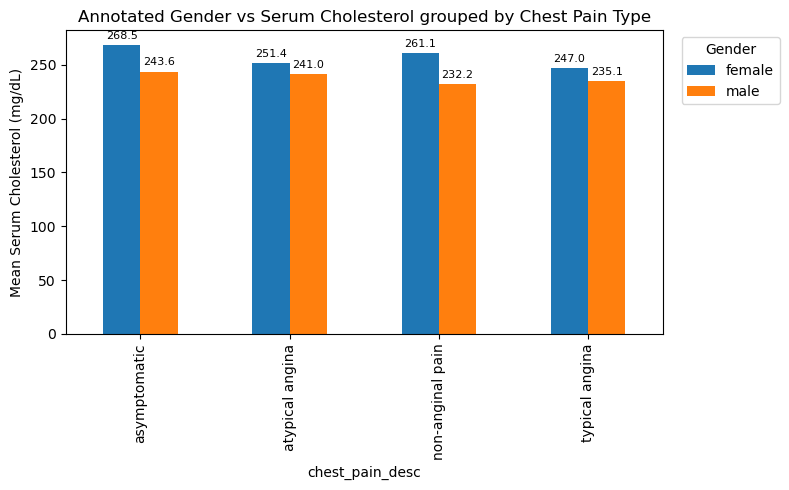

In [15]:
ax = grouped_desc.plot(kind='bar', figsize=(8,5))
plt.ylabel("Mean Serum Cholesterol (mg/dL)")
plt.title("Annotated Gender vs Serum Cholesterol grouped by Chest Pain Type")

# Annotate each bar with its numeric value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=8, xytext=(0,3),
                textcoords='offset points')

plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


# **Question 2 : (13)**

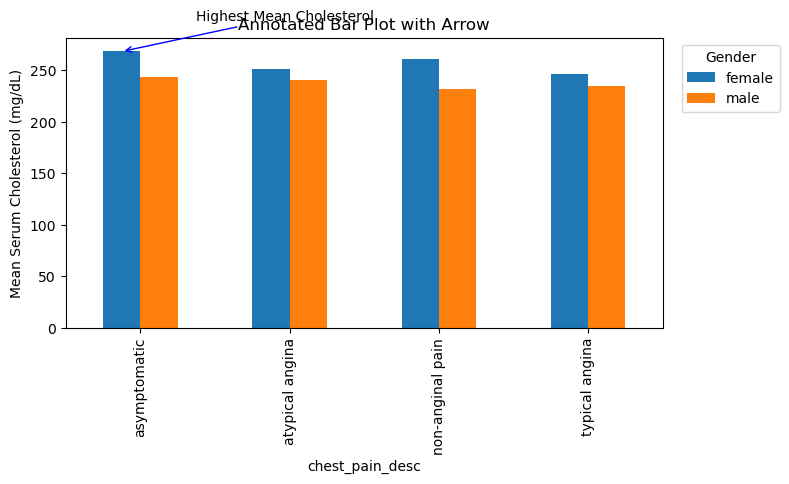

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
grouped_desc.plot(kind='bar', ax=ax)
plt.ylabel("Mean Serum Cholesterol (mg/dL)")
plt.title("Annotated Bar Plot with Arrow")

# Find the highest bar
max_val = grouped_desc.stack().max()

# Locate the patch with the highest value and annotate it
for p in ax.patches:
    if abs(p.get_height() - max_val) < 1e-6:
        x = p.get_x() + p.get_width()/2.
        y = p.get_height()
        ax.annotate('Highest Mean Cholesterol',
                    xy=(x, y), xytext=(x + 0.5, y + 30),
                    arrowprops=dict(arrowstyle='->', color='blue'),
                    color='black')
        break

plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


# **Question 2 : (14)**

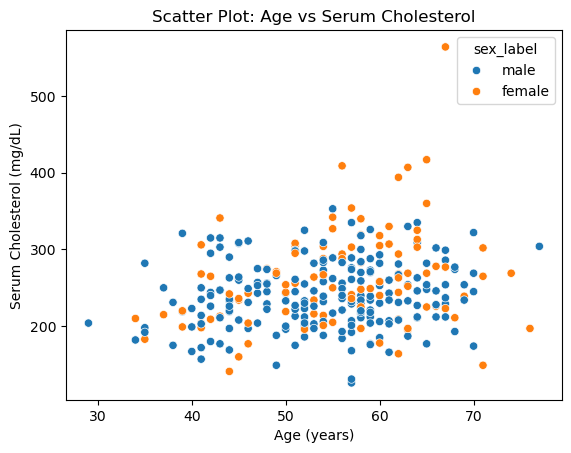

In [17]:
# Scatter plot for age vs serum cholesterol, colored by gender
sns.scatterplot(data=df, x='age', y='serum_cholesterol', hue='sex_label')
plt.title("Scatter Plot: Age vs Serum Cholesterol")
plt.xlabel("Age (years)")
plt.ylabel("Serum Cholesterol (mg/dL)")
plt.show()

In [18]:
print("""There is no strong linear relationship between age and serum cholesterol.
Cholesterol levels are widely scattered across different ages.
Most observations cluster in the age range 40–65 years, with cholesterol typically between 180–300 mg/dL.
A few outliers exist with cholesterol above 350 mg/dL, scattered across various ages.
Coloring by gender shows that both males and females share similar spreads, though males dominate in count.""")

There is no strong linear relationship between age and serum cholesterol.
Cholesterol levels are widely scattered across different ages.
Most observations cluster in the age range 40–65 years, with cholesterol typically between 180–300 mg/dL.
A few outliers exist with cholesterol above 350 mg/dL, scattered across various ages.
Coloring by gender shows that both males and females share similar spreads, though males dominate in count.


# **Question 2 : (15)**

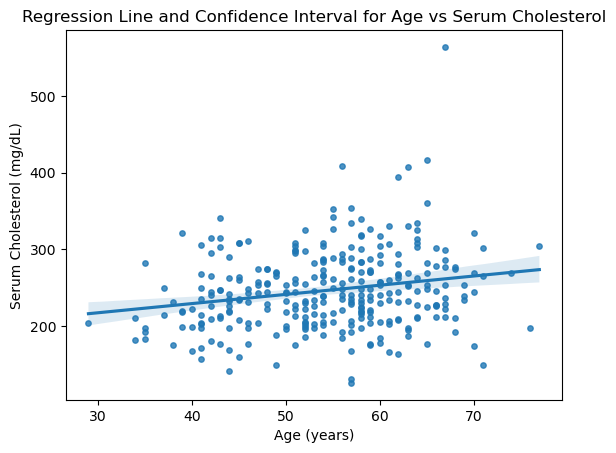

In [19]:
# Regression plot with confidence bands
sns.regplot(data=df, x='age', y='serum_cholesterol', scatter_kws={'s':15})
plt.title("Regression Line and Confidence Interval for Age vs Serum Cholesterol")
plt.xlabel("Age (years)")
plt.ylabel("Serum Cholesterol (mg/dL)")
plt.show()

In [20]:
print("""The dark central line represents the best-fit regression line, which shows the estimated trend (average relationship) between age and serum cholesterol.
The light-colored shaded band around the line represents the confidence interval (usually 95%) — it indicates the uncertainty or variability of the estimated regression line.
A narrower band means the trend estimate is more reliable; a wider band means more uncertainty.
In this dataset, the band is fairly wide, confirming that age and serum cholesterol are not strongly correlated.""")

The dark central line represents the best-fit regression line, which shows the estimated trend (average relationship) between age and serum cholesterol.
The light-colored shaded band around the line represents the confidence interval (usually 95%) — it indicates the uncertainty or variability of the estimated regression line.
A narrower band means the trend estimate is more reliable; a wider band means more uncertainty.
In this dataset, the band is fairly wide, confirming that age and serum cholesterol are not strongly correlated.


# **Question 2 : (16)**

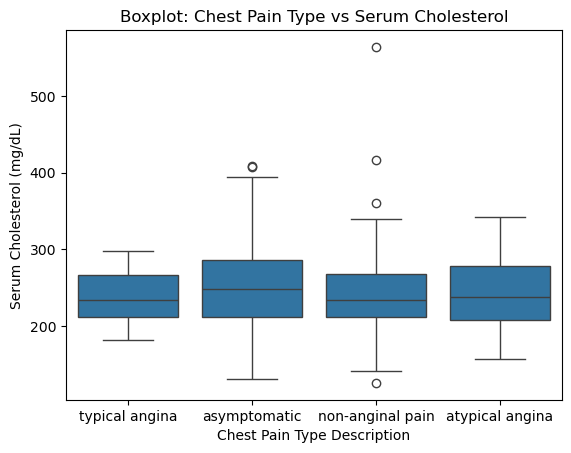

In [21]:
# Box plot for chest pain type vs serum cholesterol
sns.boxplot(data=df, x='chest_pain_desc', y='serum_cholesterol')
plt.title("Boxplot: Chest Pain Type vs Serum Cholesterol")
plt.xlabel("Chest Pain Type Description")
plt.ylabel("Serum Cholesterol (mg/dL)")
plt.show()

In [22]:
print("""The upper and lower boundaries of the box represent the 75th percentile (Q3) and 25th percentile (Q1) of the serum cholesterol distribution for each chest pain type.
The line inside the box represents the median (50th percentile) — the central value of the data.
The whiskers (error bars) extend to data points within 1.5 × IQR (interquartile range) of Q1 and Q3.
The points beyond the whiskers are outliers — unusually high or low cholesterol values relative to most observations.
These visual components together show the spread, symmetry, and presence of outliers for each category.""")

The upper and lower boundaries of the box represent the 75th percentile (Q3) and 25th percentile (Q1) of the serum cholesterol distribution for each chest pain type.
The line inside the box represents the median (50th percentile) — the central value of the data.
The whiskers (error bars) extend to data points within 1.5 × IQR (interquartile range) of Q1 and Q3.
The points beyond the whiskers are outliers — unusually high or low cholesterol values relative to most observations.
These visual components together show the spread, symmetry, and presence of outliers for each category.


# **Question 2 : (17)**

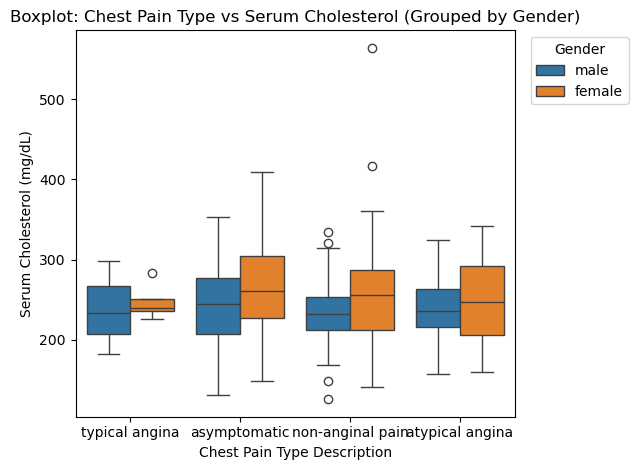

In [23]:
# Grouped box plot by gender
sns.boxplot(data=df, x='chest_pain_desc', y='serum_cholesterol', hue='sex_label')
plt.title("Boxplot: Chest Pain Type vs Serum Cholesterol (Grouped by Gender)")
plt.xlabel("Chest Pain Type Description")
plt.ylabel("Serum Cholesterol (mg/dL)")
plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
print("""The spread of cholesterol differs across chest pain types and genders.
In most categories, males show slightly higher median cholesterol levels compared to females.
The asymptomatic and non-anginal pain groups exhibit wider interquartile ranges and more outliers.
This suggests that cholesterol variability is higher among patients with less typical chest pain symptoms.""")

The spread of cholesterol differs across chest pain types and genders.
In most categories, males show slightly higher median cholesterol levels compared to females.
The asymptomatic and non-anginal pain groups exhibit wider interquartile ranges and more outliers.
This suggests that cholesterol variability is higher among patients with less typical chest pain symptoms.


# **Question 2 : (18)**

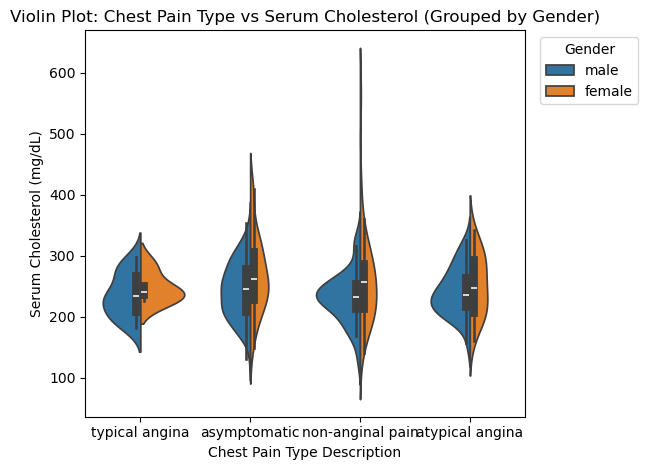

In [25]:
# Violin plot grouped by gender
sns.violinplot(data=df, x='chest_pain_desc', y='serum_cholesterol', hue='sex_label', split=True)
plt.title("Violin Plot: Chest Pain Type vs Serum Cholesterol (Grouped by Gender)")
plt.xlabel("Chest Pain Type Description")
plt.ylabel("Serum Cholesterol (mg/dL)")
plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
print("""Explanation:
Violin plots display the full distribution of cholesterol values for each chest pain type, combining features of boxplots and KDE.
The width of the violin represents the density (frequency) of observations — wider parts indicate more patients at that cholesterol level.
Split violins show males and females side by side within each category for comparison.""")

Explanation:
Violin plots display the full distribution of cholesterol values for each chest pain type, combining features of boxplots and KDE.
The width of the violin represents the density (frequency) of observations — wider parts indicate more patients at that cholesterol level.
Split violins show males and females side by side within each category for comparison.


In [27]:
print("""Observations:
Cholesterol distributions are right-skewed for several pain types.
Males generally exhibit slightly higher and more variable cholesterol values.
Some chest pain types (e.g., asymptomatic) show broader spreads, suggesting diverse cholesterol levels among such patients.
Violin plots are especially helpful in visualizing the shape and skewness of distributions beyond just summary statistics.""")

Observations:
Cholesterol distributions are right-skewed for several pain types.
Males generally exhibit slightly higher and more variable cholesterol values.
Some chest pain types (e.g., asymptomatic) show broader spreads, suggesting diverse cholesterol levels among such patients.
Violin plots are especially helpful in visualizing the shape and skewness of distributions beyond just summary statistics.
